In [1]:
# -*- coding: utf-8 -*-
"""
MGWR多年份主导因子分区图 (六边形标记)
Years: 2000, 2010, 2024
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import RegularPolygon
from matplotlib.collections import PatchCollection
import warnings
warnings.filterwarnings('ignore')

# MGWR相关库
from mgwr.sel_bw import Sel_BW
from mgwr.gwr import GWR, MGWR

# ============================================================================
# 1. 数据加载与预处理
# ============================================================================
print("=" * 60)
print("Step 1: 数据加载与预处理")
print("=" * 60)

# 加载数据
df = pd.read_csv('final_environment_with_MHI.csv')
print(f"原始数据: {df.shape[0]} 行, {df.shape[1]} 列")
# 目标年份
target_years = [2000,2005,2010,2015,2020,2024]

# ==================== 配置选项 ====================
USE_FIXED_BANDWIDTH = True
FIXED_BANDWIDTH = 20
# =================================================

# 存储各年份结果
all_results = {}

dependent_var = 'MHI'

base_independent_vars = [
    'bare_land_percent', 'cropland_percent', 'forest_percent',
    'grassland_percent', 'impervious_surface_percent',
    'shrub_percent', 
    'ntl_mean','population_mean',
    'area_mn', 'edge_density', 'largest_patch_index',
    'number_of_patches', 'patch_density', 'proportion_of_landscape',
    'mean_annual_temp', 'coldest_month_temp', 'total_annual_precip',
    'mean_annual_lst_day', 'mean_annual_sst',
    'dist_to_coast', 'water_occurrence'
]

factor_groups = {
    'bare_land_percent': 'Land cover',
    'cropland_percent': 'Land cover',
    'forest_percent': 'Land cover',
    'grassland_percent': 'Land cover',
    'impervious_surface_percent': 'Land cover',
    'shrub_percent': 'Land cover',

    'ntl_mean': 'Human activity',
    'population_mean': 'Human activity',
    'area_mn': 'Landscape pattern',
    'edge_density': 'Landscape pattern',
    'largest_patch_index': 'Landscape pattern',
    'number_of_patches': 'Landscape pattern',
    'patch_density': 'Landscape pattern',
    'proportion_of_landscape': 'Landscape pattern',

    'mean_annual_temp': 'Climate',
    'coldest_month_temp': 'Climate',
    'total_annual_precip': 'Climate',
    'mean_annual_lst_day': 'Climate',
    'mean_annual_sst': 'Climate',

    'dist_to_coast': 'Coastal/Hydrology',
    'water_occurrence': 'Coastal/Hydrology',
}

for year in sorted(df['year'].dropna().unique()):

    # 1) 筛选年份
    df_year = df[df['year'] == year].copy()

    independent_vars = base_independent_vars.copy()

    # 4) 去掉因变量缺失
    df_valid = df_year.dropna(subset=[dependent_var])
    print(f"年份 {year} 有效{dependent_var}记录: {df_valid.shape[0]} 行")

    # 5) 只保留分析字段
    use_cols = ['GridID', 'lon', 'lat', dependent_var] + independent_vars
    df_analysis = df_valid[use_cols].dropna().copy()
    print(f"年份 {year} 完整数据: {df_analysis.shape[0]} 行")

    if len(df_analysis) < 50:
        print(f"警告: 年份 {year} 数据不足，跳过")
        continue

    # 6) 提取坐标和变量
    coords = df_analysis[['lon', 'lat']].to_numpy()
    y = df_analysis[[dependent_var]].to_numpy()
    X_raw = df_analysis[independent_vars].to_numpy(dtype=float)

    # 7) 删除方差为 0 的列，避免标准化报错
    std_raw = X_raw.std(axis=0, ddof=0)
    valid_mask = std_raw > 0

    dropped_vars = [v for v, keep in zip(independent_vars, valid_mask) if not keep]
    if dropped_vars:
        print(f"年份 {year} 删除常数列: {dropped_vars}")

    independent_vars_used = [v for v, keep in zip(independent_vars, valid_mask) if keep]
    X_raw = X_raw[:, valid_mask]

    # 8) Z-score 标准化
    X_mean = X_raw.mean(axis=0)
    X_std = X_raw.std(axis=0, ddof=0)
    X = (X_raw - X_mean) / X_std

    # 9) 自动带宽选择，AICc 常用
    # 为了避免局部包含稀疏分类变量而导致的奇异矩阵错误，设置一个足够大的最小带宽(比如变量数的3倍以上)
    safe_bw_min = X.shape[1] * 4 
    print(f"年份 {year} 自动搜索带宽... (最小带宽限制: {safe_bw_min})")
    bw_selector = Sel_BW(
        coords,
        y,
        X,
        kernel='bisquare',
        fixed=False,       # 自适应带宽
        constant=True,
        spherical=True     # lon/lat 是经纬度
    )
    
    try:
        bw = bw_selector.search(criterion='AICc', bw_min=safe_bw_min)
        print(f"年份 {year} 最优带宽: {bw}")
    except Exception as e:
        print(f"年份 {year} 带宽搜索失败: {e}，跳过此年份的 GWR 拟合。")
        continue

    # 10) 拟合 GWR
    print(f"年份 {year} 拟合GWR模型...")
    gwr_model = GWR(
        coords,
        y,
        X,
        bw=bw,
        kernel='bisquare',
        fixed=False,
        constant=True,
        spherical=True
    )
    gwr_results = gwr_model.fit()

    print(f"年份 {year} R² = {gwr_results.R2:.4f}")

    # 11) 提取系数并识别主导因子
    params = gwr_results.params
    coef_matrix = params[:, 1:]   # 去掉截距列
    
    if hasattr(gwr_results, 'tvalues'):
        tvalues_matrix = gwr_results.tvalues[:, 1:]
    else:
        tvalues_matrix = (params / gwr_results.bse)[:, 1:]
    
    local_r2 = gwr_results.localR2.flatten()
    
    # 计算残差的 Moran's I
    morans_i = np.nan
    morans_p = np.nan
    try:
        from libpysal.weights import KNN
        from esda.moran import Moran
        resid = gwr_results.resid_response.flatten()
        wq = KNN.from_array(coords, k=8)
        mi = Moran(resid, wq)
        morans_i = mi.I
        morans_p = mi.p_sim
        print(f"    残差 Moran's I: {morans_i:.4f} (p={morans_p:.4f})")
    except ImportError:
        print("    未安装 libpysal 或 esda，跳过残差 Moran's I 计算。")
    except Exception as e:
        print(f"    Moran's I 计算失败: {e}")

    coef_abs = np.abs(coef_matrix)
    dominant_var_idx = np.argmax(coef_abs, axis=1)

    dominant_vars = [independent_vars_used[idx] for idx in dominant_var_idx]
    dominant_zones = [factor_groups[var] for var in dominant_vars]

    # 12) 保存结果
    results_df = df_analysis[['GridID', 'lon', 'lat', dependent_var]].copy()
    results_df['dominant_variable'] = dominant_vars
    results_df['dominant_zone'] = dominant_zones
    results_df['year'] = year
    
    # 记录额外指标
    results_df['bandwidth'] = str(bw)
    results_df['local_R2'] = local_r2
    results_df['resid_Morans_I'] = morans_i
    results_df['resid_Morans_p'] = morans_p
    
    # 记录各变量的系数和显著性检验t值
    for i, var in enumerate(independent_vars_used):
        results_df[f'coef_{var}'] = coef_matrix[:, i]
        results_df[f'tval_{var}'] = tvalues_matrix[:, i]
        # 判断显著性 (t值绝对值大于1.96，对应 alpha=0.05)
        results_df[f'sig_{var}'] = (np.abs(tvalues_matrix[:, i]) > 1.96).astype(int)

    all_results[year] = results_df

    # 13) 统计
    zone_counts = pd.Series(dominant_zones).value_counts()
    print(f"\n年份 {year} 主导因子分布:")
    for zone, count in zone_counts.items():
        pct = count / len(dominant_zones) * 100
        print(f"    {zone}: {count} ({pct:.1f}%)")

# ============================================================================
# 3. 绘制六边形分区图 (每年一张)
# ============================================================================
print("\n" + "=" * 60)
print("Step 3: 生成六边形主导因子分区图")
print("=" * 60)

# 设置期刊风格
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['font.size'] = 12
plt.rcParams['axes.linewidth'] = 0.8
plt.rcParams['axes.unicode_minus'] = False

# 颜色方案
colors = ['#D62728', '#1F77B4', '#2CA02C']  # 深红、深蓝、深绿
zone_mapping = {
    '气候敏感区': 0,
    '人类干扰主导区': 1,
    '生境破碎化主导区': 2
}

# 固定六边形大小 (1km ≈ 0.009度，使用半径)
# 六边形边到边距离为 sqrt(3) * radius，所以 radius = 1km / sqrt(3) / 111km/degree  
HEX_RADIUS = 0.008  # 约对应1km六边形的半径

for year in target_years:
    if year not in all_results:
        continue
        
    results_df = all_results[year]
    
    # 过滤掉无法映射颜色的zone
    valid_zones_mask = results_df['dominant_zone'].isin(zone_mapping.keys())
    if not valid_zones_mask.all():
        print(f"年份 {year} 中存在未能映射颜色的主导区！")
        # 降级处理
        results_df = results_df[valid_zones_mask]
    
    if len(results_df) == 0:
        continue
    
    # 创建图形
    fig, ax = plt.subplots(figsize=(10, 8), dpi=300)
    
    lons = results_df['lon'].values
    lats = results_df['lat'].values
    zones = [zone_mapping[z] for z in results_df['dominant_zone']]
    
    # 使用固定1km六边形大小
    hex_radius = HEX_RADIUS
    
    # 创建六边形patches
    patches = []
    patch_colors = []
    
    for lon, lat, zone in zip(lons, lats, zones):
        # 创建正六边形 (6边形, 旋转30度使其平顶)
        hexagon = RegularPolygon(
            (lon, lat), 
            numVertices=6, 
            radius=hex_radius,
            orientation=np.radians(30),  # 平顶六边形
        )
        patches.append(hexagon)
        patch_colors.append(colors[zone])
    
    # 添加六边形集合
    collection = PatchCollection(
        patches, 
        facecolors=patch_colors,
        edgecolors='#333333',
        linewidths=0.2,
        alpha=0.85
    )
    ax.add_collection(collection)
    
    # 设置坐标范围
    margin = 0.1
    ax.set_xlim(lons.min() - margin, lons.max() + margin)
    ax.set_ylim(lats.min() - margin, lats.max() + margin)
    
    # 添加图例
    legend_labels = [
        'Climate-sensitive',
        'Human disturbance', 
        'Habitat fragmentation'
    ]
    legend_handles = [plt.scatter([], [], c=colors[i], s=60, marker='h',
                                  edgecolors='#333333', linewidths=0.3) 
                      for i in range(3)]
    legend = ax.legend(
        handles=legend_handles, 
        labels=legend_labels,
        loc='lower right',
        fontsize=12,
        frameon=False
    )
    
    # 设置坐标轴标签
    ax.set_xlabel('Longitude', fontsize=15)
    ax.set_ylabel('Latitude', fontsize=15)
    
    # 设置刻度参数
    ax.tick_params(axis='both', which='major', labelsize=12, length=4, width=0.6)
    ax.tick_params(axis='both', which='minor', length=2, width=0.4)
    #ax.minorticks_on()
    
    # # 设置边框
    # for spine in ax.spines.values():
    #     spine.set_linewidth(0.8)
    #     spine.set_color('#333333')
    
    # 设置纵横比例
    ax.set_aspect('equal', adjustable='box')
    
    # 调整布局
    plt.tight_layout()
    
    # 保存图形
    filename_base = f'dominant_factor_{year}'
    plt.savefig(f'{filename_base}.png', dpi=600, bbox_inches='tight', 
                facecolor='white', edgecolor='none')
    print(f"已保存: {filename_base}.png/pdf")
    
    plt.show()


# ============================================================================
# 4. 合并保存所有结果
# ============================================================================
print("\n" + "=" * 60)
print("Step 4: 保存结果")
print("=" * 60)

# 合并所有年份结果
all_results_df = pd.concat(all_results.values(), ignore_index=True)
all_results_df.to_csv('mgwr_results.csv', index=False, encoding='utf-8-sig')
print(f"结果已保存至: mgwr_results.csv")

print("\n分析完成!")

Step 1: 数据加载与预处理
原始数据: 8118 行, 34 列
年份 2000 有效MHI记录: 803 行
年份 2000 完整数据: 803 行
年份 2000 自动搜索带宽... (最小带宽限制: 84)
年份 2000 最优带宽: 362.0
年份 2000 拟合GWR模型...
年份 2000 R² = 0.4773
    残差 Moran's I: 0.0410 (p=0.0040)

年份 2000 主导因子分布:
    Land cover: 655 (81.6%)
    Landscape pattern: 147 (18.3%)
    Human activity: 1 (0.1%)
年份 2005 有效MHI记录: 436 行
年份 2005 完整数据: 429 行
年份 2005 删除常数列: ['shrub_percent']
年份 2005 自动搜索带宽... (最小带宽限制: 80)
年份 2005 最优带宽: 213.0
年份 2005 拟合GWR模型...
年份 2005 R² = 0.4781
    残差 Moran's I: 0.0076 (p=0.3230)

年份 2005 主导因子分布:
    Landscape pattern: 429 (100.0%)
年份 2010 有效MHI记录: 725 行
年份 2010 完整数据: 712 行
年份 2010 自动搜索带宽... (最小带宽限制: 84)
年份 2010 最优带宽: 444.0
年份 2010 拟合GWR模型...
年份 2010 R² = 0.3084
    残差 Moran's I: 0.0208 (p=0.1040)

年份 2010 主导因子分布:
    Landscape pattern: 435 (61.1%)
    Land cover: 275 (38.6%)
    Coastal/Hydrology: 2 (0.3%)
年份 2015 有效MHI记录: 865 行
年份 2015 完整数据: 850 行
年份 2015 删除常数列: ['shrub_percent']
年份 2015 自动搜索带宽... (最小带宽限制: 80)
年份 2015 最优带宽: 658.0
年份 2015 拟合GWR模型...
年份 2

生成组合图...


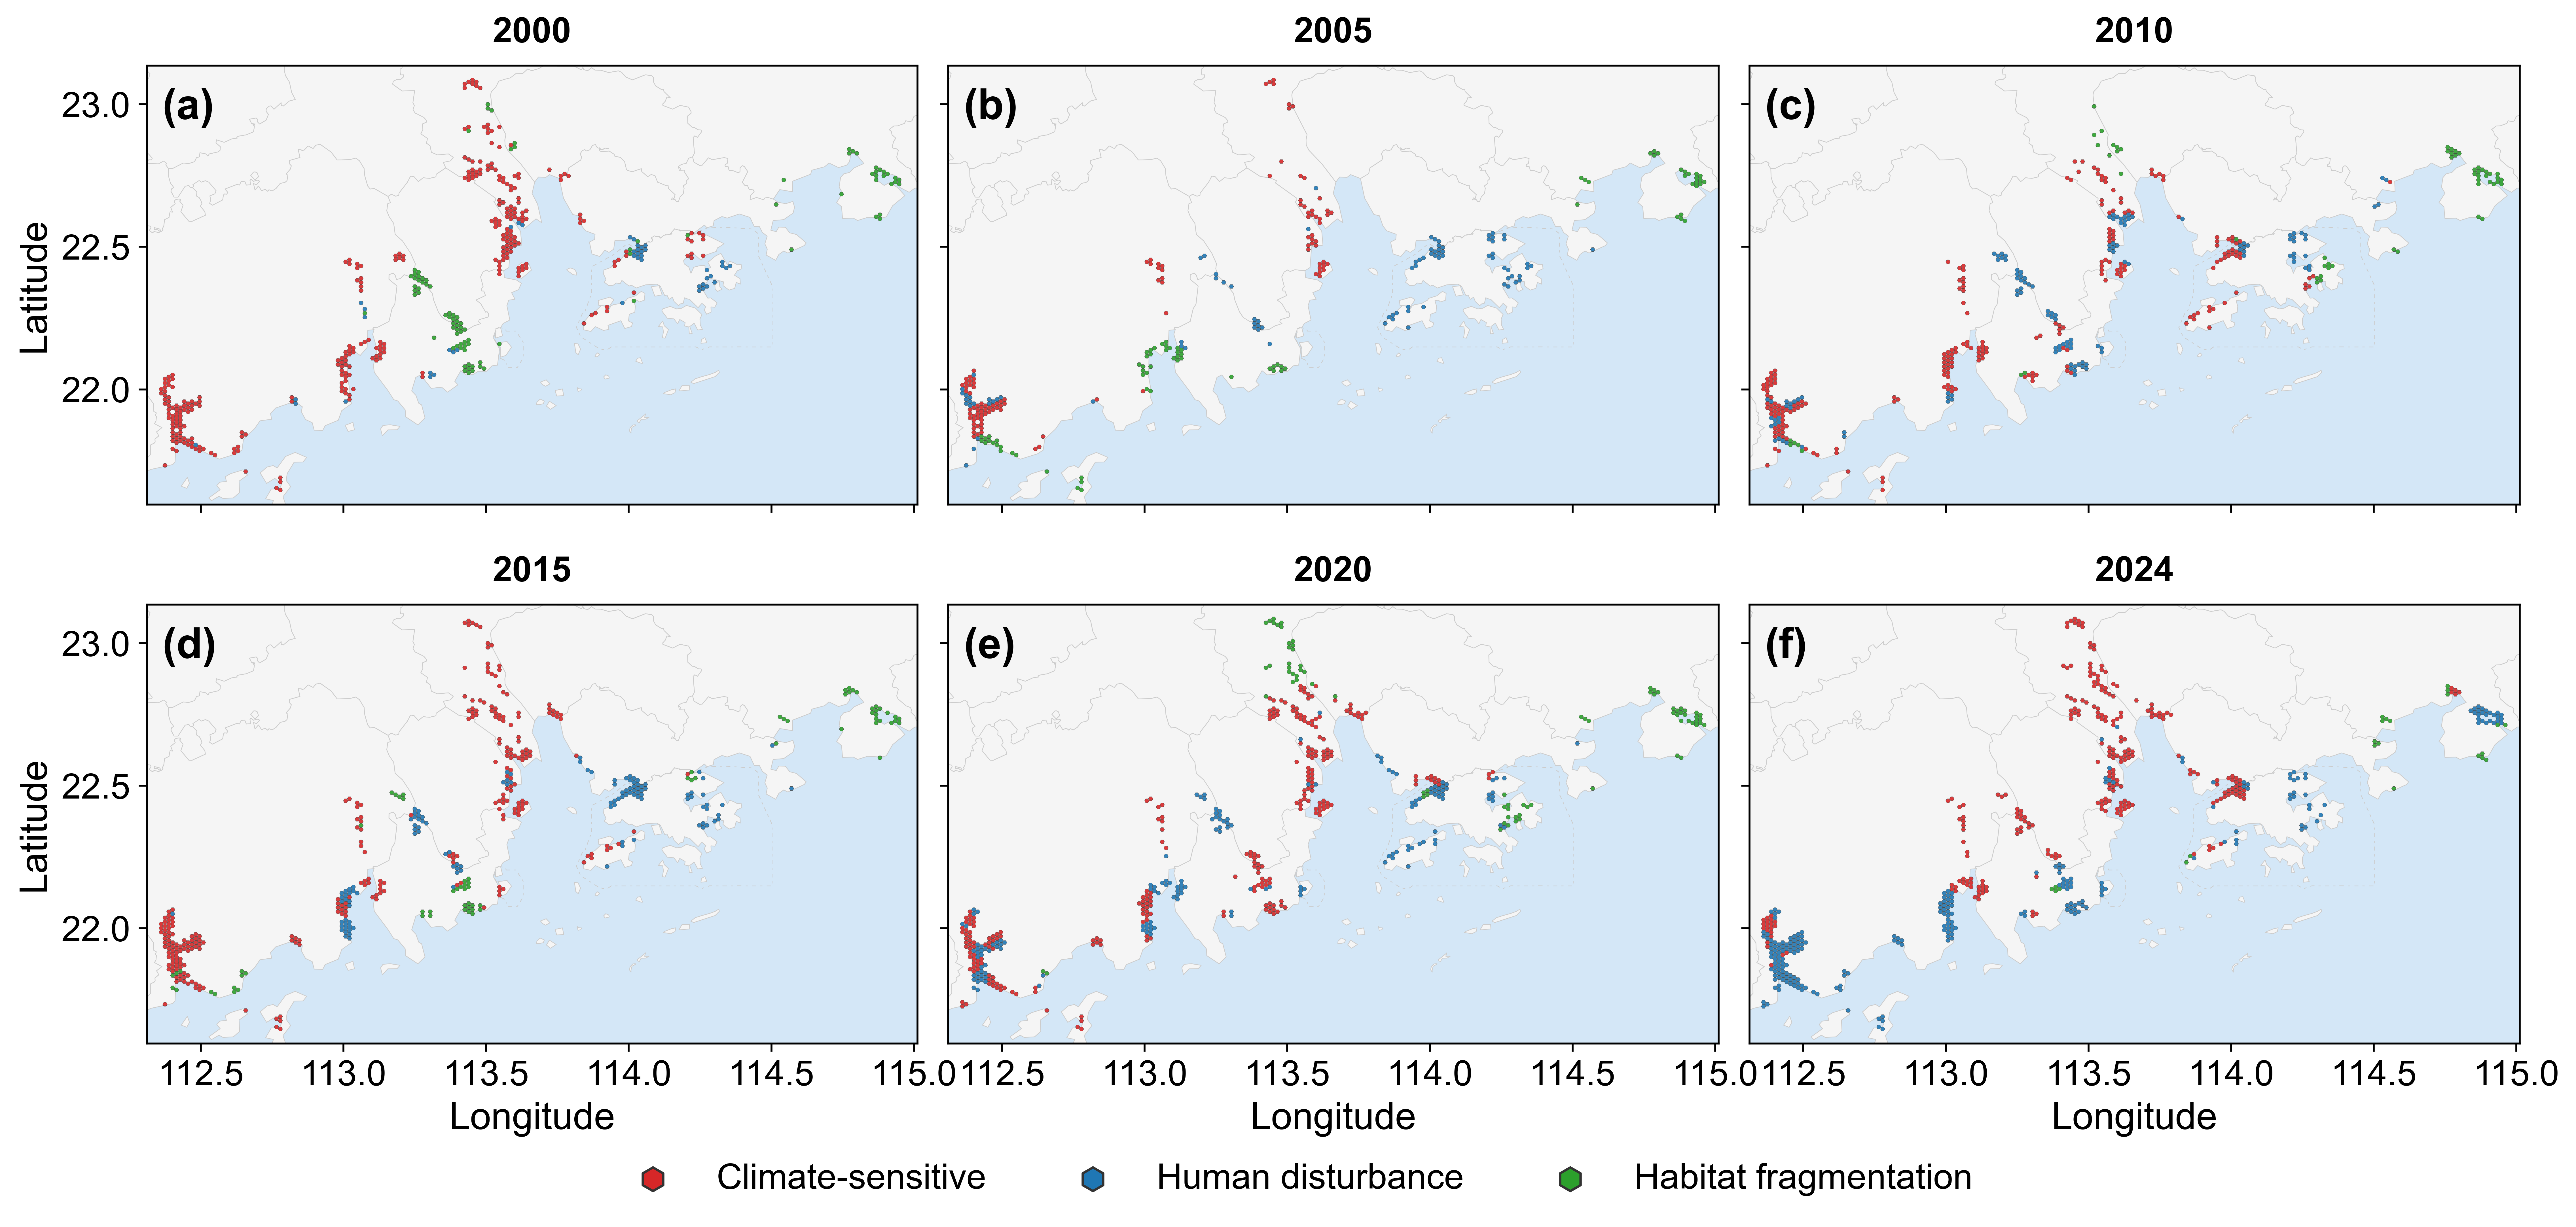

组合图已保存为 combined_gwr_zones.png


In [2]:
"""
MGWR多年份主导因子分区组合图 (六边形标记)
Years: 2000, 2010, 2024
"""

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import RegularPolygon
from matplotlib.collections import PatchCollection
import warnings
warnings.filterwarnings('ignore')

# MGWR相关库
from mgwr.sel_bw import Sel_BW
from mgwr.gwr import GWR, MGWR

# ============================================================================
# 1. 数据加载与预处理 (保持不变)
# ============================================================================
df = pd.read_csv('final_environmental_vars_with_MHI.csv')

dependent_var = 'MHI'
independent_vars = [
    'mean_annual_sst', 'proportion_of_landscape', 'population_mean',
    'water_occurrence', 'water_percent', 'mean_annual_temp',
    'cropland_percent', 'impervious_surface_percent', 'dist_to_coast',
    'patch_density'
]

factor_groups = {
    'mean_annual_sst': '气候敏感区', 'mean_annual_temp': '气候敏感区',
    'population_mean': '人类干扰主导区', 'impervious_surface_percent': '人类干扰主导区',
    'cropland_percent': '人类干扰主导区', 'dist_to_coast': '人类干扰主导区',
    'proportion_of_landscape': '生境破碎化主导区', 'water_occurrence': '生境破碎化主导区',
    'water_percent': '生境破碎化主导区', 'patch_density': '生境破碎化主导区'
}

target_years = [2000,2005,2010,2015,2020,2024]
FIXED_BANDWIDTH = 40
all_results = {}

# ============================================================================
# 2. 对每个年份分别进行GWR分析 (逻辑保持不变)
# ============================================================================
for year in target_years:
    df_year = df[df['year'] == year].copy().dropna(subset=['MHI'])
    df_analysis = df_year[['GridID', 'lon', 'lat', dependent_var] + independent_vars].dropna()
    
    if len(df_analysis) < 50: continue
    
    coords = df_analysis[['lon', 'lat']].values
    y = df_analysis[dependent_var].values.reshape(-1, 1)
    X_raw = df_analysis[independent_vars].values
    X = (X_raw - X_raw.mean(axis=0)) / X_raw.std(axis=0)
    
    gwr_model = GWR(coords, y, X, bw=FIXED_BANDWIDTH, constant=True)
    gwr_results = gwr_model.fit()
    
    coef_abs = np.abs(gwr_results.params[:, 1:])
    dominant_var_idx = np.argmax(coef_abs, axis=1)
    dominant_zones = [factor_groups[independent_vars[idx]] for idx in dominant_var_idx]
    
    results_df = df_analysis[['GridID', 'lon', 'lat']].copy()
    results_df['dominant_zone'] = dominant_zones
    all_results[year] = results_df

# ============================================================================
# 3. 绘制组合图 (a)(b)(c)
# ============================================================================
print("生成组合图...")

# 设置样式
plt.rcParams['font.family'] = 'Arial'
colors = ['#D62728', '#1F77B4', '#2CA02C']  # 红、蓝、绿
zone_mapping = {'气候敏感区': 0, '人类干扰主导区': 1, '生境破碎化主导区': 2}
HEX_RADIUS = 0.008 

# 加载底图
basemap_path = 'buffer/中国_市.geojson'
try:
    basemap_gdf = gpd.read_file(basemap_path)
    # Ensure CRS matches if necessary, though simpler to assume compatible coordinates for now
except Exception as e:
    print(f"Warning: Could not load basemap: {e}")
    basemap_gdf = None
 

# 创建 1行3列 的画布
fig, axes = plt.subplots(2, 3, figsize=(18, 8), dpi=600, sharex='col', sharey='row')
plt.subplots_adjust(wspace=0.04, hspace=0.06)
sub_labels = ['(a)', '(b)', '(c)', '(d)', '(e)', '(f)']

# 确定全局坐标范围，保证三张图尺度一致
all_lons = pd.concat([res['lon'] for res in all_results.values()])
all_lats = pd.concat([res['lat'] for res in all_results.values()])
lon_min, lon_max = all_lons.min() - 0.05, all_lons.max() + 0.05
lat_min, lat_max = all_lats.min() - 0.05, all_lats.max() + 0.05

axes = axes.flatten()

for i, year in enumerate(target_years):
    ax = axes[i]
    res_df = all_results[year]
    
    # Step 1: Fill the entire background with light blue (ocean color)
    ocean_color = '#d4e7f7'  # Light blue for ocean
    ax.set_facecolor(ocean_color)
    
    # Step 2: Draw the base map (land areas in light gray/white)
    if basemap_gdf is not None and not basemap_gdf.empty:
        basemap_gdf.plot(
            ax=ax,
            facecolor='#f5f5f5',  # Light gray for land
            edgecolor='#cccccc',  # Gray border for city boundaries
            linewidth=0.3,
            zorder=1
        )

    
    patches = []
    patch_colors = []
    
    for _, row in res_df.iterrows():
        hexagon = RegularPolygon(
            (row['lon'], row['lat']), 
            numVertices=6, 
            radius=HEX_RADIUS,
            orientation=np.radians(30)
        )
        patches.append(hexagon)
        patch_colors.append(colors[zone_mapping[row['dominant_zone']]])
    
    collection = PatchCollection(patches, facecolors=patch_colors, edgecolors='#333333', linewidths=0.1, alpha=0.9)
    ax.add_collection(collection)
    
    # 设置子图属性
    ax.set_xlim(lon_min, lon_max)
    ax.set_ylim(lat_min, lat_max)
    ax.set_aspect('equal')
    ax.set_title(f'{year}', fontsize=15, fontweight='bold', pad=10)
    ax.tick_params(axis='both', which='major', labelsize=15)
    
    # 添加左上角标 (a, b, c)
    # x=0.02, y=0.95 表示在子图内部左上角
    ax.text(0.02, 0.95, sub_labels[i], transform=ax.transAxes, 
            fontsize=18, fontweight='bold', va='top', ha='left')

    if i >= 3:
        ax.set_xlabel('Longitude', fontsize=16)
    if i % 3 == 0:
        ax.set_ylabel('Latitude', fontsize=16)

# 添加共享坐标轴标签 (已移至子图循环中)
# fig.supxlabel('Longitude', fontsize=15)
# fig.supylabel('Latitude', fontsize=15)

# 创建全局统一图例
legend_labels = ['Climate-sensitive', 'Human disturbance', 'Habitat fragmentation']
legend_handles = [plt.scatter([], [], c=colors[i], s=100, marker='h', edgecolors='#333333') for i in range(3)]

fig.legend(
    handles=legend_handles, 
    labels=legend_labels,
    loc='lower center', 
    bbox_to_anchor=(0.5, 0.0),
    ncol=3, 
    fontsize=15,
    frameon=False
)

# 保存
plt.savefig('combined_gwr_zones.png', dpi=600, bbox_inches='tight')
plt.show()

print("组合图已保存为 combined_gwr_zones.png")
